## Scatter Matrix

1. Подключение к db.

In [8]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix


conn = sqlite3.connect("../data/checking-logs.sqlite")

2. Формирование датафрейма pageviews.

In [9]:
query_pageviews = """
SELECT uid, COUNT(datetime) as pageviews
FROM pageviews
WHERE uid NOT LIKE "admin%"
GROUP BY uid
"""

df_pageviews = pd.read_sql(query_pageviews, conn)

df_pageviews.head(10)

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


3. Формирование датафрейма commits.

In [10]:
query_commits = """
SELECT uid, COUNT(timestamp) AS num_commits 
FROM checker
WHERE uid NOT LIKE "admin%" AND labname != "project1"
GROUP BY uid
"""

df_commits = pd.read_sql(query_commits, conn)

df_commits.head(10)

,uid,num_commits
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86
5,user_13,52
6,user_14,61
7,user_15,23
8,user_16,41
9,user_17,51


4. Формирование датафрейма avg.

In [11]:
query_avg = """
SELECT uid, AVG((julianday(t.first_commit_ts) - julianday(datetime(d.deadlines, 'unixepoch'))) * 24) AS avg_diff 
FROM test AS t
JOIN deadlines as d ON LOWER(t.labname) = LOWER(d.labs)
WHERE labname != "project1"
GROUP BY t.uid
"""

df_avg = pd.read_sql(query_avg, conn)

df_avg.head(10)

,uid,avg_diff
0,user_1,-65.119644
1,user_10,-75.242310
2,user_14,-159.568696
3,user_17,-62.207513
4,user_18,-6.367907
5,user_19,-99.440298
6,user_21,-96.111041
7,user_25,-93.474751
8,user_28,-86.793652
9,user_3,-105.738041


5. Merge фреймов для графика.

In [ ]:
df = pd.merge(df_avg, df_pageviews, on="uid", how="inner")
df = pd.merge(df, df_commits, on='uid', how="inner")
df

(11, 4)

6. Построение графика.

array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

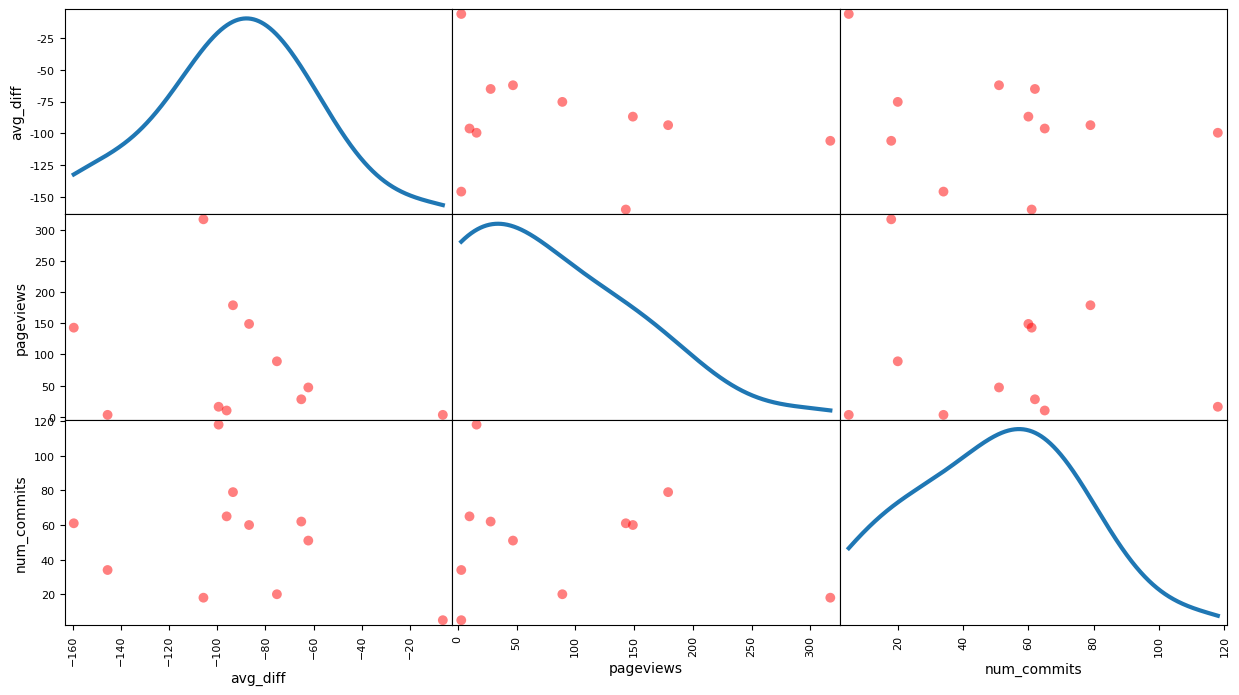

In [13]:
scatter_matrix(
    df, 
    diagonal='kde', 
    density_kwds={'linewidth': 3}, 
    figsize=(15, 8), 
    c="red", 
    s=200)

In [14]:
conn.close()

Вопросы:

Можно ли сказать, что если у пользователя мало просмотров страниц, то, скорее всего, у него и мало коммитов? Ответ: Нет

Можно ли сказать, что если у пользователя мало просмотров страниц, то, скорее всего, у него небольшая средняя разница между первым коммитом и дедлайном в лабораторной? Ответ: Нет

Можно ли сказать, что есть много пользователей с небольшим количеством коммитов и несколько пользователей с большим количеством коммитов? Ответ: Да

Можно ли сказать, что есть много пользователей с небольшой средней разницей и несколько пользователей с большой средней разницей? Ответ: Нет